In [ ]:

# MIWAF PHASE 2 - MACHINE LEARNING
# Notebook 4: Crime Risk Scorer
# Author: Mbugua Hellen Njeri | Reg No: 24/05982
# Description: Predict crime risk level at water collection points — Low, Medium or High risk

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix)
from xgboost import XGBClassifier

In [4]:
#Load the dataset
notebook_dir = os.getcwd()
outputs_dir = os.path.join(notebook_dir, 'outputs')
models_dir = os.path.join(notebook_dir, 'models')
os.makedirs(models_dir, exist_ok=True)

df = pd.read_csv( os.path.join(outputs_dir, 'model3_crime_data.csv'))
print(f" Shape: {df.shape}")
print(f"\nFirst 5 rows")
print(df.head())
print(f"\n Risk Level Breakdown")
risk_map = {0: 'Low', 1: 'Medium', 2: 'High'}
print(df['risk_level'].map(risk_map).value_counts())

 Shape: (77226, 4)

First 5 rows
   incident_hour  incident_day  gender_encoded  risk_level
0              4             4               0           1
1              5             4               0           0
2              6             4               0           2
3              6             4               0           0
4              8             4               0           1

 Risk Level Breakdown
risk_level
Medium    37535
High      24534
Low       15157
Name: count, dtype: int64


In [6]:
#Separate inputs from target
X = df[[
    'incident_hour',
    'incident_day',
    'gender_encoded'
]]
y = df['risk_level']

print(f" X shape: {X.shape}")
print(f" y shape : {y.shape}")
print(f"\n Features used:")
for col in X.columns:
    print(f" {col}")
print(f"\n Target: risk_level")
print(f" 0 = Low risk")
print(f" 1 = Medium risk")
print(f" 2 = High risk")

 X shape: (77226, 3)
 y shape : (77226,)

 Features used:
 incident_hour
 incident_day
 gender_encoded

 Target: risk_level
 0 = Low risk
 1 = Medium risk
 2 = High risk


In [8]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f" Training set: {X_train.shape[0]} rows(80%)")
print(f" Testing set: {X_test.shape[0]} rows(20%)")
print(f"\nRisk level distribution in training set:")
print(y_train.map(risk_map).value_counts())

 Training set: 61780 rows(80%)
 Testing set: 15446 rows(20%)

Risk level distribution in training set:
risk_level
Medium    30028
High      19627
Low       12125
Name: count, dtype: int64


In [10]:
#Scale features
scaler_c = StandardScaler()
X_train_scaled = scaler_c.fit_transform(X_train)
X_test_scaled = scaler_c.transform(X_test)

#Save Scaler
with open(
    os.path.join(models_dir, 'scaler_crime.pkl'), 'wb'
)as f:
    pickle.dump(scaler_c, f)

In [12]:
#Train Logistic Regression
print("Training using Logistic Regression Algorithm")
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    multi_class='multinomial' 
)
lr_model.fit(X_train_scaled, y_train)

lr_predictions = lr_model.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test, lr_predictions)

print(f" Accuracy : {lr_accuracy*100:.2f}%")
print(f"\nDetailed Report:")
print(classification_report(y_test,lr_predictions,target_names=['Low','Medium', 'High']))

Training using Logistic Regression Algorithm
 Accuracy : 48.60%

Detailed Report:
              precision    recall  f1-score   support

         Low       0.00      0.00      0.00      3032
      Medium       0.49      1.00      0.65      7507
        High       0.00      0.00      0.00      4907

    accuracy                           0.49     15446
   macro avg       0.16      0.33      0.22     15446
weighted avg       0.24      0.49      0.32     15446



In [16]:
#Train Random Forest
print('Training using Random Forest Algorithm')
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled,y_train)

rf_predictions = rf_model.predict(X_test_scaled)
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f" Accuracy : {rf_accuracy*100:.2f}%")
print(f"\nDetailed Report:")
print(classification_report(y_test,rf_predictions,target_names=['Low','Medium','High']))

Training using Random Forest Algorithm
 Accuracy : 48.04%

Detailed Report:
              precision    recall  f1-score   support

         Low       0.24      0.01      0.02      3032
      Medium       0.49      0.98      0.65      7507
        High       0.28      0.01      0.02      4907

    accuracy                           0.48     15446
   macro avg       0.34      0.33      0.23     15446
weighted avg       0.37      0.48      0.33     15446



In [19]:
#Train using XGBoost
print('Training using XGBoost Algorithm')
xgb_model = XGBClassifier(
    n_estimators = 100,
    random_state = 42,
    versobility = 0,
    eval_metric = 'mlogloss',
    num_class = 3
)
xgb_model.fit(X_train_scaled, y_train)
xgb_predictions = xgb_model.predict(X_test_scaled)
xgb_accuracy = accuracy_score(y_test,xgb_predictions)

print(f" Accuracy : {xgb_accuracy*100:.2f}%")
print(f"\nDetailed Report:")
print(classification_report(y_test,xgb_predictions,target_names=['Low', 'Medium', 'High']))

Training using XGBoost Algorithm
 Accuracy : 48.12%

Detailed Report:
              precision    recall  f1-score   support

         Low       0.25      0.01      0.02      3032
      Medium       0.49      0.98      0.65      7507
        High       0.29      0.01      0.02      4907

    accuracy                           0.48     15446
   macro avg       0.34      0.33      0.23     15446
weighted avg       0.38      0.48      0.33     15446



In [31]:
results = pd.DataFrame({
    'Model'    : ['Logistic Regression',
                  'Random Forest',
                  'XGBoost'],
    'Accuracy' : [lr_accuracy*100,
                  rf_accuracy*100,
                  xgb_accuracy*100]
})

results['Accuracy'] = results['Accuracy'].round(2)
results = results.sort_values(
    'Accuracy', ascending=False
).reset_index(drop=True)  

print("=" * 45)
print("   MODEL COMPARISON — CRIME RISK SCORER")
print("=" * 45)
print(results.to_string(index=False))
print("=" * 45)
print(f"\nBest Model: {results.iloc[0]['Model']}")
print(f"   Accuracy  : {results.iloc[0]['Accuracy']}%")

   MODEL COMPARISON — CRIME RISK SCORER
              Model  Accuracy
Logistic Regression     48.60
            XGBoost     48.12
      Random Forest     48.04

Best Model: Logistic Regression
   Accuracy  : 48.6%


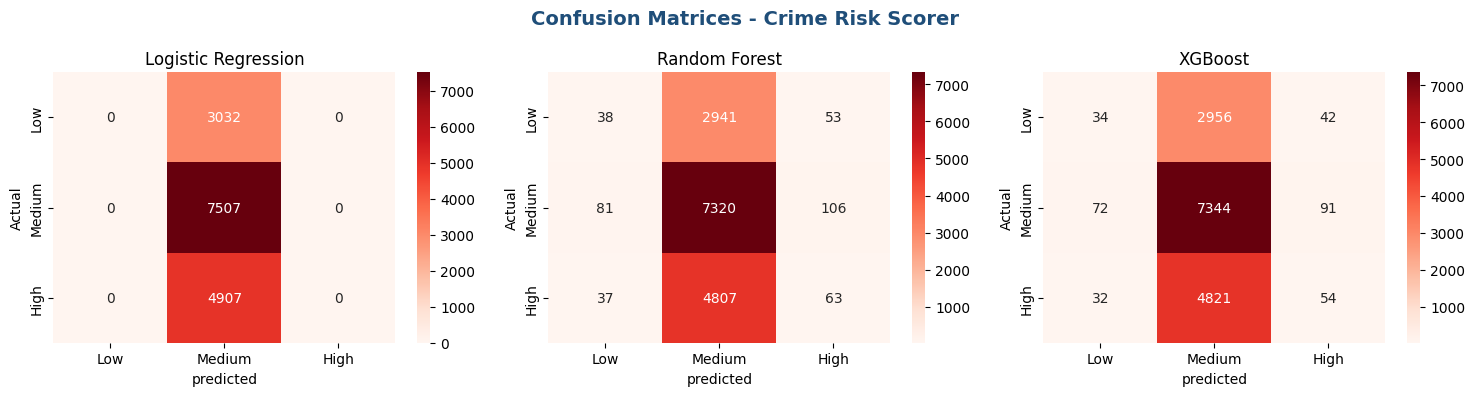

In [34]:
#Confusion Matrix
fig, axes = plt.subplots(1,3, figsize=(15,4))
fig.suptitle( 'Confusion Matrices - Crime Risk Scorer', fontsize = 14, fontweight= 'bold', color = '#1F4E79')
models_list = [
    ('Logistic Regression', lr_predictions),
    ('Random Forest', rf_predictions),
    ('XGBoost', xgb_predictions)
]
for ax, (name, preds) in zip(axes, models_list):
    cm = confusion_matrix(y_test,preds)
    sns.heatmap(
        cm,annot=True, fmt='d', cmap='Reds', ax=ax,
        xticklabels=['Low','Medium','High'],
        yticklabels=['Low','Medium','High']
    )
    ax.set_title(name)
    ax.set_xlabel('predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig(
    os.path.join(outputs_dir, 'crime_confusion_matrix.png'), dpi=150, bbox_inches = 'tight'
)
plt.show()

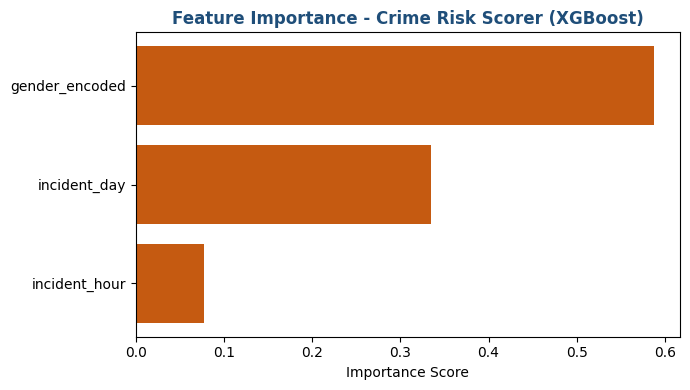

In [38]:
#Feature Importance
feature_names = ['incident_hour', 'incident_day','gender_encoded']

importance_df = pd.DataFrame({
    'Feature'  : feature_names,
    'Importance' : xgb_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(7,4))
plt.barh(
    importance_df['Feature'], importance_df['Importance'], color='#C55A11'
)
plt.title('Feature Importance - Crime Risk Scorer (XGBoost)', fontweight='bold', color='#1F4E79')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig( os.path.join(outputs_dir, "crime_feature_importance.png"), dpi=150, bbox_inches = 'tight')
plt.show()

In [40]:
#Save Best Model
best_accuracy = max(lr_accuracy, rf_accuracy, xgb_accuracy)

if best_accuracy == xgb_accuracy:
    best_model      = xgb_model
    best_model_name = 'XGBoost'
elif best_accuracy == rf_accuracy:
    best_model      = rf_model
    best_model_name = 'Random Forest'
else:
    best_model      = lr_model
    best_model_name = 'Logistic Regression'

with open(
    os.path.join(models_dir, 'crime_model.pkl'), 'wb'
) as f:
    pickle.dump(best_model, f)

print(f"   Model    : {best_model_name}")
print(f"   Accuracy : {best_accuracy*100:.2f}%")
print(f"   Saved to : models/crime_model.pkl")

   Model    : Logistic Regression
   Accuracy : 48.60%
   Saved to : models/crime_model.pkl
